In [1]:
#preprocessing 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\raw\Produktivitas_Jagung_Kota_Kabupaten_Jabar.csv")

df = df[
    [
        "nama_kabupaten_kota",
        "tahun",
        "produktivitas_jagung"
    ]
]

df.columns = [
    "kabupaten",
    "tahun",
    "produktivitas"
]

df["kabupaten"] = (
    df["kabupaten"]
    .str.upper()
    .str.replace("KABUPATEN ", "", regex=False)
    .str.replace("KOTA ", "", regex=False)
    .str.strip()
)

df["komoditas"] = "Jagung"

df.to_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\clean\jagung_clean.csv",
    index=False
)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   kabupaten      216 non-null    str    
 1   tahun          216 non-null    int64  
 2   produktivitas  216 non-null    float64
 3   komoditas      216 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 9.8 KB


In [3]:
df.shape

(216, 4)

In [4]:
print(df.describe())

            tahun  produktivitas
count   216.00000     216.000000
mean   2018.50000      54.497176
std       2.29661      27.823765
min    2015.00000       0.000000
25%    2016.75000      47.122500
50%    2018.50000      64.860000
75%    2020.25000      75.045000
max    2022.00000      91.110000


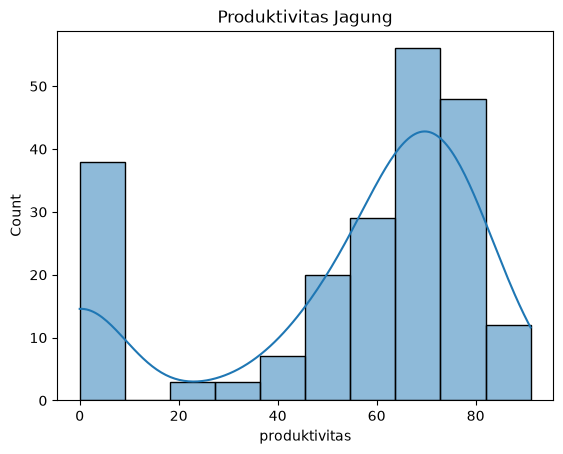

In [5]:
sns.histplot(
    df["produktivitas"],
    kde=True
)

plt.title("Produktivitas Jagung")
plt.show()

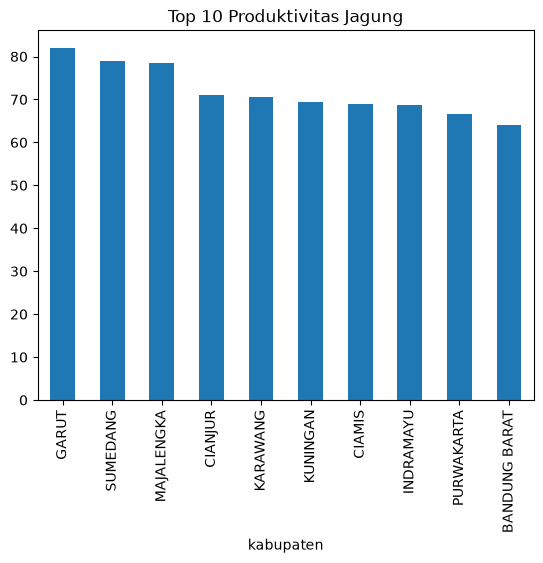

In [6]:
top = (
    df.groupby("kabupaten")
    ["produktivitas"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top.plot(
    kind="bar"
)

plt.title(
    "Top 10 Produktivitas Jagung"
)

plt.show()

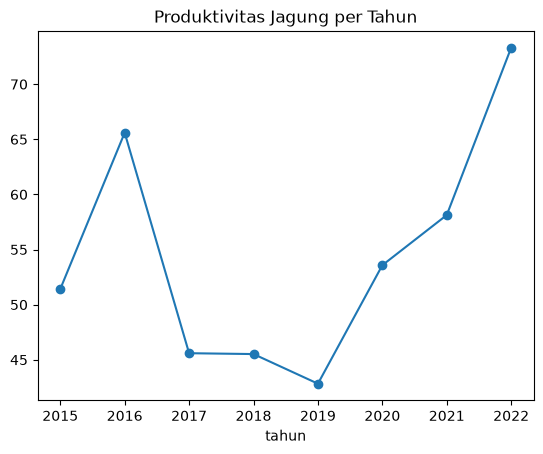

In [8]:
yearly = (
    df.groupby("tahun")
    ["produktivitas"]
    .mean()
)

yearly.plot(
    marker="o"
)

plt.title(
    "Produktivitas Jagung per Tahun"
)

plt.show()

<Axes: xlabel='tahun', ylabel='produktivitas'>

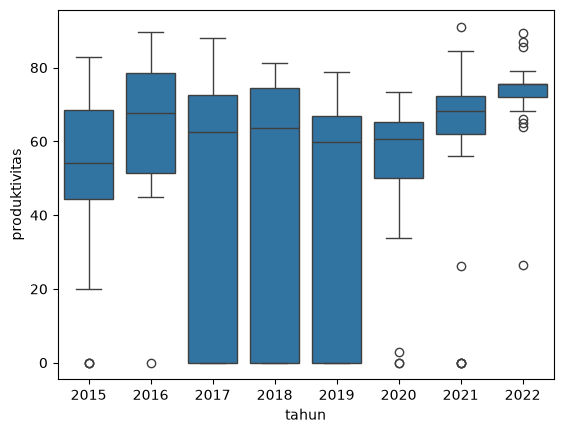

In [10]:
sns.boxplot(
    x="tahun",
    y="produktivitas",
    data=df
)